# Section - XGBoost Model

TRY NEW MODEL - APRIL 2026 <br>
Updated on  : 21/04/2026 

# 1. Load Function

In [2]:
import pandas as pd
import numpy as np
import re
import pickle
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# 2. Load Files

In [3]:
# ============================================================
# 📂 LOAD & COMBINE ALL PROJECT FILES
# ============================================================
print("=" * 100)
print("📊 LOADING DATA")
print("=" * 100)

folder_path = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\dummy_data"

dfs = []
for file in os.listdir(folder_path):
    if file.endswith(".xlsx"):
        path = os.path.join(folder_path, file)
        try:
            df_temp = pd.read_excel(path)
            df_temp.columns = df_temp.columns.str.upper()
            dfs.append(df_temp)
            print(f"   ✅ Loaded: {file} — {len(df_temp)} rows")
        except Exception as e:
            print(f"   ⚠ Skipped ({e}): {file}")

if not dfs:
    raise ValueError("No Excel files found or loaded from the specified folder.")

df = pd.concat(dfs, ignore_index=True)

print(f"\n   Total records: {len(df)}")
print(f"   Columns: {', '.join(df.columns)}")
print(f"\n📋 Preview:\n{df.head(10)}")


📊 LOADING DATA
   ✅ Loaded: Oiltek_A1706.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9991.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9992.xlsx — 93 rows
   ✅ Loaded: Oiltek_A9993.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9994.xlsx — 108 rows
   ✅ Loaded: Oiltek_A9995.xlsx — 108 rows
   ✅ Loaded: UGS_A2027.xlsx — 328 rows
   ✅ Loaded: UGS_A8881.xlsx — 86 rows
   ✅ Loaded: UGS_A8882.xlsx — 115 rows
   ✅ Loaded: UGS_A8883.xlsx — 115 rows
   ✅ Loaded: UGS_A8884.xlsx — 115 rows
   ✅ Loaded: UGS_A8885.xlsx — 116 rows

   Total records: 1568
   Columns: CUSTOMER, PROJECT, SECTION, CLUSTER, DEVICE_ID

📋 Preview:
  CUSTOMER PROJECT    SECTION    CLUSTER DEVICE_ID
0   OILTEK   A1706  SECTION 1  CLUSTER 1      A500
1   OILTEK   A1706  SECTION 1  CLUSTER 1     HT500
2   OILTEK   A1706  SECTION 1  CLUSTER 1    PT500A
3   OILTEK   A1706  SECTION 1  CLUSTER 1    PV500B
4   OILTEK   A1706  SECTION 1  CLUSTER 1     TE500
5   OILTEK   A1706  SECTION 2  CLUSTER 1    HLA600
6   OILTEK   A1706  SECTION 2  CLUSTER 1     DV60

# 3.Feature Engineering

In [4]:

# ============================================================
# 🔧 FEATURE ENGINEERING
# ============================================================
print("\n" + "=" * 100)
print("🔧 FEATURE ENGINEERING (PROJECT-AWARE)")
print("=" * 100)

def extract_numeric_block(device_id):
    """Extract the first continuous numeric block. e.g. HLA600 → 600, PT500A → 500"""
    match = re.search(r'\d+', str(device_id))
    return int(match.group()) if match else -1

def extract_prefix(device_id):
    """Extract alphabetic prefix before numeric block. e.g. HLA600 → HLA, A500 → A"""
    match = re.match(r'^([A-Za-z]+)', str(device_id))
    return match.group(1).upper() if match else ''

def extract_suffix_letters(device_id):
    """Extract trailing letters after numeric block. e.g. PT500A → A, A500 → ''"""
    match = re.search(r'\d+([A-Za-z]*)$', str(device_id))
    return match.group(1).upper() if match else ''

def extract_suffix_full(device_id):
    """Extract everything after numeric block (letters + digits + symbols). e.g. PT500A1.2 → A1.2"""
    match = re.search(r'\d+(.*)$', str(device_id))
    return match.group(1) if match else ''

def extract_section_num(section_str):
    """e.g. 'SECTION 1' → 1"""
    digits = ''.join(c for c in str(section_str) if c.isdigit())
    return int(digits) if digits else 0

def extract_cluster_num(cluster_str):
    """e.g. 'CLUSTER 1' → 1"""
    digits = ''.join(c for c in str(cluster_str) if c.isdigit())
    return int(digits) if digits else 0


# ── BASIC DEVICE ID FEATURES ────────────────────────────────
df['numeric_block']     = df['DEVICE_ID'].apply(extract_numeric_block)
df['device_prefix']     = df['DEVICE_ID'].apply(extract_prefix)
df['device_suffix_letter']  = df['DEVICE_ID'].apply(extract_suffix_letters)  
df['suffix_full']       = df['DEVICE_ID'].apply(extract_suffix_full)     
df['prefix_length']     = df['device_prefix'].str.len()
df['device_id_length']  = df['DEVICE_ID'].astype(str).str.len()
df['has_suffix_letter'] = (df['device_suffix_letter'] != '').astype(int)
df['has_numeric']       = (df['numeric_block'] != -1).astype(int)

# ──  SUFFIX FEATURES ────────────────────────────
print("\n   Creating advanced suffix features...")

# 1. Full suffix analysis (includes letters, digits, decimals)
df['suffix_length']             = df['suffix_full'].astype(str).str.len()
df['suffix_has_digit']          = df['suffix_full'].astype(str).str.contains(r'\d', regex=True).astype(int)
df['suffix_has_letter']         = df['suffix_full'].astype(str).str.contains(r'[A-Za-z]', regex=True).astype(int)
df['suffix_has_decimal']        = df['suffix_full'].astype(str).str.contains(r'\.', regex=True).astype(int)
df['suffix_digit_count']        = df['suffix_full'].astype(str).str.count(r'\d')
df['suffix_letter_count']       = df['suffix_full'].astype(str).str.count(r'[A-Za-z]')
df['suffix_starts_with_digit']  = df['suffix_full'].astype(str).str[0].str.isdigit().fillna(0).astype(int)

# 2. Suffix character analysis (KEY for customer-specific patterns)
df['suffix_last_char']            = df['suffix_full'].astype(str).str[-1]
df['suffix_last_char_is_letter']  = df['suffix_last_char'].str.isalpha().fillna(0).astype(int)
df['suffix_last_char_is_digit']   = df['suffix_last_char'].str.isdigit().fillna(0).astype(int)

# 3. Equipment ID features (DEVICE_ID analysis)
df['equip_id_length']       = df['DEVICE_ID'].astype(str).str.len()
df['equip_id_digit_count']  = df['DEVICE_ID'].astype(str).str.count(r'\d')
df['equip_id_letter_count'] = df['DEVICE_ID'].astype(str).str.count(r'[A-Za-z]')

print("   ✅ Advanced suffix features created")

# ── KEY FEATURE: relative rank of numeric block within project ──────────────

df['numeric_block_rank_in_project'] = (
    df.groupby(['CUSTOMER', 'PROJECT'])['numeric_block']
    .transform(lambda x: pd.cut(x, bins=len(x.unique()), labels=False, duplicates='drop') + 1
               if x.nunique() > 1 else 1)
)

# Simpler and more robust: rank unique numeric blocks per project
def assign_block_rank(group):
    unique_blocks = sorted(group['numeric_block'].unique())
    block_to_rank = {b: i + 1 for i, b in enumerate(unique_blocks)}
    return group['numeric_block'].map(block_to_rank)

df['numeric_block_rank'] = df.groupby(['CUSTOMER', 'PROJECT'], group_keys=False).apply(assign_block_rank)

print("   ✅ numeric_block_rank: rank of numeric block within project (1=lowest)")
print(f"\n   Sample feature preview:")
print(df[['CUSTOMER', 'PROJECT', 'DEVICE_ID', 'numeric_block', 'suffix_full', 
          'suffix_length', 'suffix_last_char', 'numeric_block_rank', 'SECTION']].head(15))




🔧 FEATURE ENGINEERING (PROJECT-AWARE)

   Creating advanced suffix features...
   ✅ Advanced suffix features created
   ✅ numeric_block_rank: rank of numeric block within project (1=lowest)

   Sample feature preview:
   CUSTOMER PROJECT DEVICE_ID  numeric_block suffix_full  suffix_length  \
0    OILTEK   A1706      A500            500                          0   
1    OILTEK   A1706     HT500            500                          0   
2    OILTEK   A1706    PT500A            500           A              1   
3    OILTEK   A1706    PV500B            500           B              1   
4    OILTEK   A1706     TE500            500                          0   
5    OILTEK   A1706    HLA600            600                          0   
6    OILTEK   A1706     DV601            601                          0   
7    OILTEK   A1706     FB601            601                          0   
8    OILTEK   A1706    HLA601            601                          0   
9    OILTEK   A1706    LLA601  

# 4. Label Encoding

In [5]:

# ============================================================
# 🔤 ENCODE CATEGORICAL VARIABLES
# ============================================================
print("\n" + "=" * 100)
print("🔤 ENCODING CATEGORICAL VARIABLES")
print("=" * 100)

le_customer       = LabelEncoder()
le_project        = LabelEncoder()
le_prefix         = LabelEncoder()
le_suffix_letter  = LabelEncoder()
le_suffix_last    = LabelEncoder()  
le_section        = LabelEncoder()
le_cluster        = LabelEncoder()

df['customer_enc']         = le_customer.fit_transform(df['CUSTOMER'])
df['project_enc']          = le_project.fit_transform(df['PROJECT'])
df['prefix_enc']           = le_prefix.fit_transform(df['device_prefix'])
df['suffix_letter_enc']    = le_suffix_letter.fit_transform(df['device_suffix_letter'])
df['suffix_last_char_enc'] = le_suffix_last.fit_transform(df['suffix_last_char'])  # NEW
df['section_enc']          = le_section.fit_transform(df['SECTION'])
df['cluster_enc']          = le_cluster.fit_transform(df['CLUSTER'])

print(f"   Section classes: {list(le_section.classes_)}")
print(f"   Cluster classes: {list(le_cluster.classes_)}")


🔤 ENCODING CATEGORICAL VARIABLES
   Section classes: ['SECTION 1', 'SECTION 2', 'SECTION 3', 'SECTION 4', 'SECTION 5', 'SECTION 6']
   Cluster classes: ['CLUSTER 1', 'CLUSTER 2', 'CLUSTER 3', 'CLUSTER 4', 'CLUSTER 5', 'CLUSTER 6', 'CLUSTER 7', 'CLUSTER 8', 'CLUSTER 9']


# 5. Features & Targets

In [6]:

# ============================================================
# 🎯 FEATURES & TARGETS
# ============================================================
feature_columns = [
    'DEVICE_ID',
    # Original features
    'customer_enc',
    'project_enc',
    'numeric_block',
    'numeric_block_rank',
    'prefix_enc',
    'suffix_letter_enc',
    'prefix_length',
    'device_id_length',
    'has_suffix_letter',
    'has_numeric',
    
    # NEW: Advanced suffix features
    'suffix_length',
    'suffix_has_digit',
    'suffix_has_letter',
    'suffix_has_decimal',
    'suffix_digit_count',
    'suffix_letter_count',
    'suffix_starts_with_digit',
    'suffix_last_char_enc',
    'suffix_last_char_is_letter',
    'suffix_last_char_is_digit',
    
    # NEW: Equipment ID features
    'equip_id_length',
    'equip_id_digit_count',
    'equip_id_letter_count',
]

X = df[feature_columns]
y_section = df['section_enc']
y_cluster = df['cluster_enc']

print(f"\n   Total features: {len(feature_columns)}")
print(f"   Feature list: {feature_columns}")



   Total features: 24
   Feature list: ['DEVICE_ID', 'customer_enc', 'project_enc', 'numeric_block', 'numeric_block_rank', 'prefix_enc', 'suffix_letter_enc', 'prefix_length', 'device_id_length', 'has_suffix_letter', 'has_numeric', 'suffix_length', 'suffix_has_digit', 'suffix_has_letter', 'suffix_has_decimal', 'suffix_digit_count', 'suffix_letter_count', 'suffix_starts_with_digit', 'suffix_last_char_enc', 'suffix_last_char_is_letter', 'suffix_last_char_is_digit', 'equip_id_length', 'equip_id_digit_count', 'equip_id_letter_count']


In [7]:
print(df.columns)
print(X.columns)


Index(['CUSTOMER', 'PROJECT', 'SECTION', 'CLUSTER', 'DEVICE_ID',
       'numeric_block', 'device_prefix', 'device_suffix_letter', 'suffix_full',
       'prefix_length', 'device_id_length', 'has_suffix_letter', 'has_numeric',
       'suffix_length', 'suffix_has_digit', 'suffix_has_letter',
       'suffix_has_decimal', 'suffix_digit_count', 'suffix_letter_count',
       'suffix_starts_with_digit', 'suffix_last_char',
       'suffix_last_char_is_letter', 'suffix_last_char_is_digit',
       'equip_id_length', 'equip_id_digit_count', 'equip_id_letter_count',
       'numeric_block_rank_in_project', 'numeric_block_rank', 'customer_enc',
       'project_enc', 'prefix_enc', 'suffix_letter_enc',
       'suffix_last_char_enc', 'section_enc', 'cluster_enc'],
      dtype='object')
Index(['DEVICE_ID', 'customer_enc', 'project_enc', 'numeric_block',
       'numeric_block_rank', 'prefix_enc', 'suffix_letter_enc',
       'prefix_length', 'device_id_length', 'has_suffix_letter', 'has_numeric',
       's

# 6. Run Model - TRAIN/VAL/TEST 

In [8]:
# ============================================================
# ✂️ TRAIN / VAL / TEST SPLIT (DataFrame-based)
# ============================================================
print("\n" + "=" * 100)
print("✂️  SPLITTING DATA")
print("=" * 100)

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


def safe_split_df(df, label_col, test_size=0.15, val_size=0.176, max_attempts=100):
    y = df[label_col]
    all_classes = set(np.unique(y))

    for attempt in range(max_attempts):
        idx_tmp, idx_test = train_test_split(
            df.index,
            test_size=test_size,
            random_state=42 + attempt,
            stratify=y,
            shuffle=True
        )

        idx_train, idx_val = train_test_split(
            idx_tmp,
            test_size=val_size,
            random_state=42 + attempt,
            stratify=y.loc[idx_tmp],
            shuffle=True
        )

        if set(np.unique(y.loc[idx_train])) == all_classes:
            print(f"   ✅ Valid split on attempt {attempt + 1}")
            break
    else:
        print("   ⚠ Using last split (not all classes in train)")

    train_df = df.loc[idx_train].copy().reset_index(drop=False)
    val_df   = df.loc[idx_val].copy().reset_index(drop=False)
    test_df  = df.loc[idx_test].copy().reset_index(drop=False)

    train_df["_split"] = "train"
    val_df["_split"]   = "val"
    test_df["_split"]  = "test"

    return train_df, val_df, test_df


# ✅ Build full DataFrame
full_df = X.copy()
full_df["y_section"] = y_section
full_df["y_cluster"] = y_cluster

# ✅ Split
train_df, val_df, test_df = safe_split_df(full_df, label_col="y_section")

# ✅ Feature cols
feature_cols = X.columns.tolist()

# ✅ Extract features
def extract_features(df, cols):
    X_out = df[cols].apply(pd.to_numeric, errors='coerce')
    bad   = X_out.dtypes[X_out.dtypes == 'object'].index.tolist()
    if bad:
        print(f"   ⚠ Dropping non-numeric columns: {bad}")
        X_out = X_out.drop(columns=bad)
    X_out = X_out.fillna(0)
    return X_out

X_train = extract_features(train_df, feature_cols)
X_val   = extract_features(val_df,   feature_cols)
X_test  = extract_features(test_df,  feature_cols)

y_sec_train = train_df["y_section"]
y_sec_val   = val_df["y_section"]
y_sec_test  = test_df["y_section"]

y_clu_train = train_df["y_cluster"]
y_clu_val   = val_df["y_cluster"]
y_clu_test  = test_df["y_cluster"]

# ✅ Diagnostics
print(f"\n   Train : {len(train_df):,} rows")
print(f"   Val   : {len(val_df):,} rows")
print(f"   Test  : {len(test_df):,} rows")
print(f"   Feature shape (train) : {X_train.shape}")
print(f"   Dtype breakdown       :\n{X_train.dtypes.value_counts()}")
print(f"\n   Sample train_df (with origin index):")
print(train_df[["index", "y_section", "y_cluster", "_split"]].head(5))


# ============================================================
# 🚀 TRAIN — SECTION MODEL
# ============================================================
print("\n" + "=" * 100)
print("🚀 TRAINING — SECTION MODEL")
print("=" * 100)

def build_model(n_classes):
    return xgb.XGBClassifier(
        objective        = 'multi:softprob',
        num_class        = n_classes,
        max_depth        = 6,
        learning_rate    = 0.05,
        n_estimators     = 300,
        min_child_weight = 1,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        gamma            = 0.1,
        random_state     = 42,
        eval_metric      = 'mlogloss',
    )

model_section = build_model(len(le_section.classes_))
model_section.fit(
    X_train, y_sec_train,
    eval_set=[(X_train, y_sec_train), (X_val, y_sec_val)],
    verbose=False
)

y_sec_pred = model_section.predict(X_test)

print(f"\n   🎯 Section Test Accuracy: {accuracy_score(y_sec_test, y_sec_pred):.2%}")
print(classification_report(
    y_sec_test, y_sec_pred,
    target_names=le_section.classes_,
    zero_division=0
))


# ============================================================
# 🚀 TRAIN — CLUSTER MODEL
# ============================================================
print("\n" + "=" * 100)
print("🚀 TRAINING — CLUSTER MODEL")
print("=" * 100)

model_cluster = build_model(len(le_cluster.classes_))
model_cluster.fit(
    X_train, y_clu_train,
    eval_set=[(X_train, y_clu_train), (X_val, y_clu_val)],
    verbose=False
)

y_clu_pred = model_cluster.predict(X_test)

print(f"\n   🎯 Cluster Test Accuracy: {accuracy_score(y_clu_test, y_clu_pred):.2%}")
print(classification_report(
    y_clu_test, y_clu_pred,
    target_names=le_cluster.classes_,
    zero_division=0
))


✂️  SPLITTING DATA
   ✅ Valid split on attempt 1

   Train : 1,097 rows
   Val   : 235 rows
   Test  : 236 rows
   Feature shape (train) : (1097, 24)
   Dtype breakdown       :
int64      23
float64     1
Name: count, dtype: int64

   Sample train_df (with origin index):
   index  y_section  y_cluster _split
0    858          0          8  train
1     63          3          3  train
2    392          2          3  train
3    710          0          0  train
4   1402          1          1  train

🚀 TRAINING — SECTION MODEL

   🎯 Section Test Accuracy: 99.58%
              precision    recall  f1-score   support

   SECTION 1       1.00      0.99      0.99        71
   SECTION 2       1.00      1.00      1.00        54
   SECTION 3       0.98      1.00      0.99        46
   SECTION 4       1.00      1.00      1.00        23
   SECTION 5       1.00      1.00      1.00        38
   SECTION 6       1.00      1.00      1.00         4

    accuracy                           1.00       236
 

### Generate dataframe each dataset

In [ ]:
# generate dataframe for each tarining, validation and testing dataset

train_df2 = train_df[["index", "DEVICE_ID", "y_section", "y_cluster","_split"]]
train_df2["actual_section"] = le_section.inverse_transform(train_df2["y_section"])
train_df2["actual_cluster"] = le_cluster.inverse_transform(train_df2["y_cluster"])

test_df2 = test_df[["index", "DEVICE_ID", "y_section", "y_cluster","_split"]]
test_df2["actual_section"] = le_section.inverse_transform(test_df2["y_section"])
test_df2["actual_cluster"] = le_cluster.inverse_transform(test_df2["y_cluster"])

val_df2 = val_df[["index", "DEVICE_ID", "y_section", "y_cluster","_split"]]
val_df2["actual_section"] = le_section.inverse_transform(val_df2["y_section"])
val_df2["actual_cluster"] = le_cluster.inverse_transform(val_df2["y_cluster"])


In [ ]:
# Add predictions
test_df2["pred_section"] = y_sec_pred
test_df2["pred_cluster"] = y_clu_pred

# Decode predictions
test_df2["pred_section"] = le_section.inverse_transform(test_df2["pred_section"])
test_df2["pred_cluster"] = le_cluster.inverse_transform(test_df2["pred_cluster"])

# Final dataframe
final_df = test_df2[[
    "DEVICE_ID",
    "actual_section",
    "pred_section",
    "actual_cluster",
    "pred_cluster"
]]

# pd.set_option('display.max_rows', None)

# print(final_df)

final_df.columns

final_df["check"] = (
    (final_df["actual_section"] == final_df["pred_section"]) &
    (final_df["actual_cluster"] == final_df["pred_cluster"])
)


In [ ]:
print(final_df[final_df["check"]==False])

📊 Training Output Result <br>



| DEVICE_ID | Actual Section | Predicted Section | Check Section | Actual Cluster | Predicted Cluster | Check   |
| --------- | -------------- | ----------------- | ------------- | -------------- | ----------------- | ------- |
| CPM6311   | SECTION 1      | SECTION 1         | ✅ True        | CLUSTER 3      | CLUSTER 4         | ❌ False |
| FIT151    | SECTION 3      | SECTION 3         | ✅ True        | CLUSTER 4      | CLUSTER 1         | ❌ False |
| HT275     | SECTION 1      | SECTION 3         | ❌ False       | CLUSTER 1      | CLUSTER 1         | ✅ True  |
| V29011    | SECTION 3      | SECTION 3         | ✅ True        | CLUSTER 7      | CLUSTER 4         | ❌ False |
| LLA093    | SECTION 3      | SECTION 3         | ✅ True        | CLUSTER 3      | CLUSTER 1         | ❌ False |







# 8 Feature Importance


⭐ FEATURE IMPORTANCE

   [SECTION]
                   feature  importance
             numeric_block    0.205721
          suffix_has_digit    0.150301
        suffix_digit_count    0.108072
        numeric_block_rank    0.100482
             suffix_length    0.093298
      equip_id_digit_count    0.049733
               project_enc    0.048372
     equip_id_letter_count    0.047095
             prefix_length    0.036677
                prefix_enc    0.034146
          device_id_length    0.031761
        suffix_has_decimal    0.027661
           equip_id_length    0.023202
         suffix_letter_enc    0.021138
      suffix_last_char_enc    0.014904
         has_suffix_letter    0.007437
              customer_enc    0.000000
         suffix_has_letter    0.000000
               has_numeric    0.000000
suffix_last_char_is_letter    0.000000
  suffix_starts_with_digit    0.000000
       suffix_letter_count    0.000000
 suffix_last_char_is_digit    0.000000

   Top 10 features for SECT

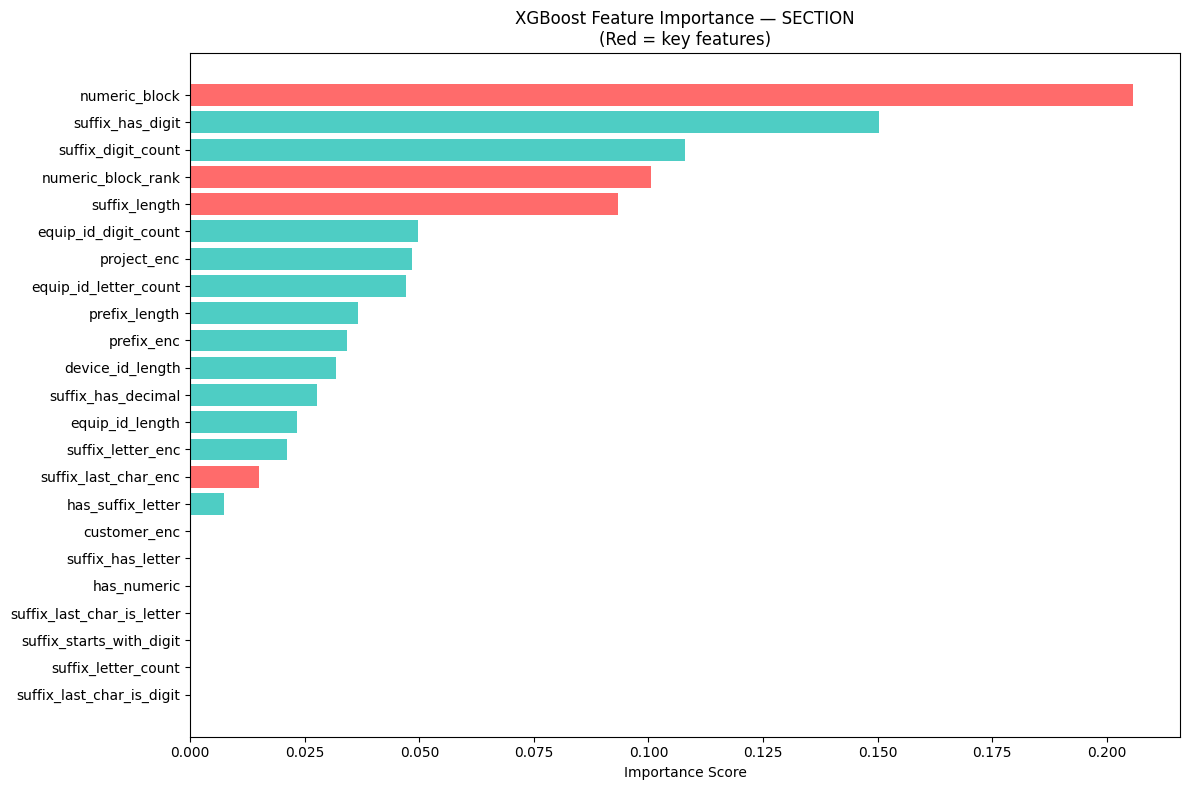


   [CLUSTER]
                   feature  importance
        suffix_has_decimal    0.174605
      suffix_last_char_enc    0.114115
 suffix_last_char_is_digit    0.107410
             suffix_length    0.097792
     equip_id_letter_count    0.072900
        suffix_digit_count    0.069399
          suffix_has_digit    0.046759
        numeric_block_rank    0.041725
      equip_id_digit_count    0.037645
             numeric_block    0.036933
         has_suffix_letter    0.032420
           equip_id_length    0.032349
             prefix_length    0.029283
          device_id_length    0.027508
         suffix_letter_enc    0.026124
                prefix_enc    0.024453
         suffix_has_letter    0.012774
               project_enc    0.009911
       suffix_letter_count    0.005895
              customer_enc    0.000000
               has_numeric    0.000000
suffix_last_char_is_letter    0.000000
  suffix_starts_with_digit    0.000000

   Top 10 features for CLUSTER:
                 

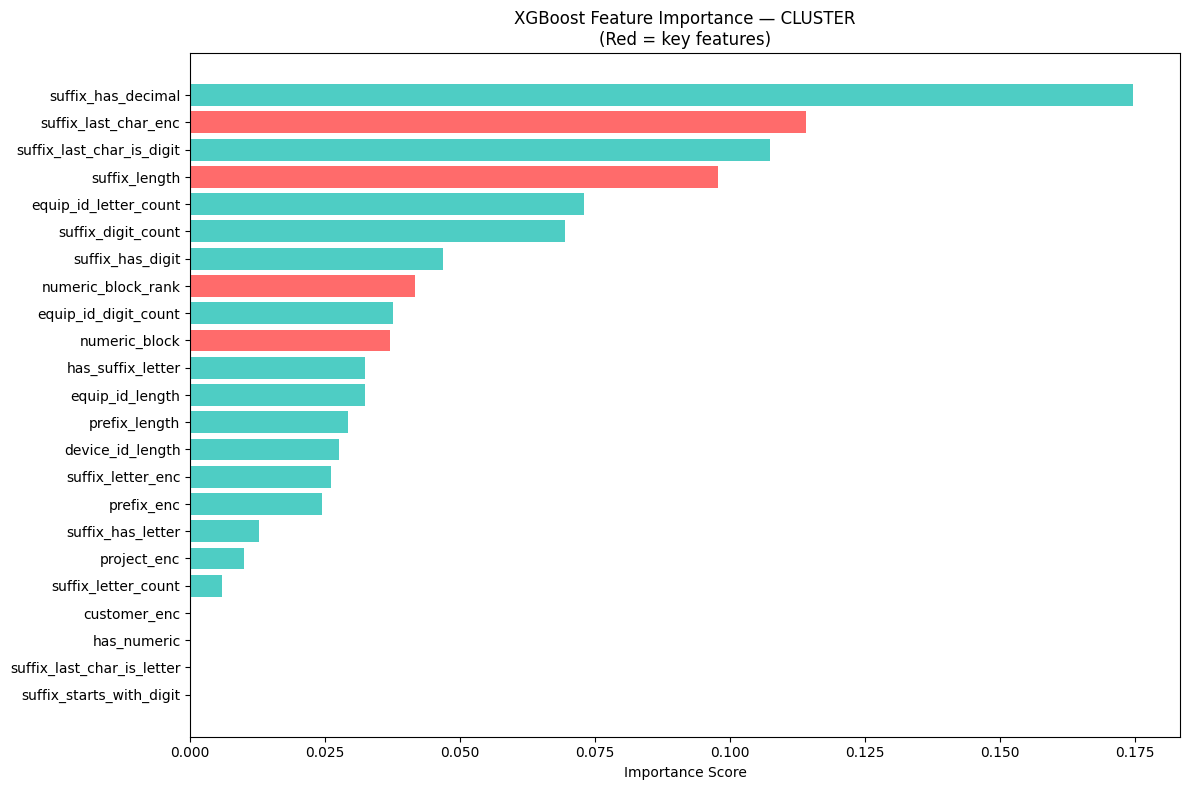


💾 SAVING MODEL AND ENCODERS
   ✅ Saved: model_section.pkl, model_cluster.pkl, label_encoders.pkl

   📋 Saved 23 features:
       1. customer_enc
       2. project_enc
       3. numeric_block
       4. numeric_block_rank
       5. prefix_enc
       6. suffix_letter_enc
       7. prefix_length
       8. device_id_length
       9. has_suffix_letter
      10. has_numeric
      11. suffix_length
      12. suffix_has_digit
      13. suffix_has_letter
      14. suffix_has_decimal
      15. suffix_digit_count
      16. suffix_letter_count
      17. suffix_starts_with_digit
      18. suffix_last_char_enc
      19. suffix_last_char_is_letter
      20. suffix_last_char_is_digit
      21. equip_id_length
      22. equip_id_digit_count
      23. equip_id_letter_count


In [ ]:

# ============================================================
# ⭐ FEATURE IMPORTANCE
# ============================================================
print("\n" + "=" * 100)
print("⭐ FEATURE IMPORTANCE")
print("=" * 100)

# NEW: Highlight multiple important features
key_features = ['numeric_block_rank', 'suffix_last_char_enc', 'suffix_length', 
                'numeric_block']  # Add features you want to highlight

for label, model in [("SECTION", model_section), ("CLUSTER", model_cluster)]:
    fi = pd.DataFrame({
        'feature'   : feature_columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\n   [{label}]\n{fi.to_string(index=False)}")
    
    # NEW: Show top 10 most important features
    print(f"\n   Top 10 features for {label}:")
    print(fi.head(10).to_string(index=False))

    # UPDATED: Color code multiple key features
    colors = ['#ff6b6b' if f in key_features else '#4ecdc4' for f in fi['feature']]
    plt.figure(figsize=(12, 8))  # Increased size for more features
    plt.barh(fi['feature'], fi['importance'], color=colors)
    plt.xlabel('Importance Score')
    plt.title(f'XGBoost Feature Importance — {label}\n(Red = key features)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()



# 9. Save Files

In [ ]:
# ============================================================
# 💾 SAVE
# ============================================================
print("\n" + "=" * 100)
print("💾 SAVING MODEL AND ENCODERS")
print("=" * 100)

SAVE_DIR = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\model_config"
os.makedirs(SAVE_DIR, exist_ok=True)

with open(os.path.join(SAVE_DIR, "model_section.pkl"), "wb") as f:
    pickle.dump(model_section, f)

with open(os.path.join(SAVE_DIR, "model_cluster.pkl"), "wb") as f:
    pickle.dump(model_cluster, f)

# CRITICAL: Save ALL encoders including the new one
with open(os.path.join(SAVE_DIR, "label_encoders.pkl"), "wb") as f:
    pickle.dump({
        'customer'       : le_customer,
        'project'        : le_project,
        'prefix'         : le_prefix,
        'suffix_lt'      : le_suffix_letter,
        'suffix_last'    : le_suffix_last,      # ← NEW: Don't forget this!
        'section'        : le_section,
        'cluster'        : le_cluster,
        'feature_columns': feature_columns,    
    }, f)

print("   ✅ Saved: model_section.pkl, model_cluster.pkl, label_encoders.pkl")

# NEW: Save feature names for verification
print(f"\n   📋 Saved {len(feature_columns)} features:")
for i, feat in enumerate(feature_columns, 1):
    print(f"      {i:2d}. {feat}")

# --Finish --

### Save column [customer, project, device id, numeric block]

In [ ]:
df_oiltek_num = df[["CUSTOMER", "PROJECT", "SECTION", "CLUSTER", "DEVICE_ID", "numeric_block"]]
df_oiltek_num.to_pickle(
    r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\model_config\df_oiltek_num.pkl"
)

### to do next? <br>
cross tabulation distribution for result testing actual vs prediction ✅ <br>
